<a href="https://www.kaggle.com/code/sonawanelalitsunil/understanding-pcos-ml-100?scriptVersionId=234591579" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/polycystic-ovary-syndrome-pcos/pcos_rotterdam_balanceado.csv


## Title: Understanding PCOS

In [2]:
df = pd.read_csv('/kaggle/input/polycystic-ovary-syndrome-pcos/pcos_rotterdam_balanceado.csv')

In [3]:
df.head()

,Age,BMI,Menstrual_Irregularity,Testosterone_Level(ng/dL),Antral_Follicle_Count,PCOS_Diagnosis
0,29,21.2,0,46.1,9,0
1,20,20.5,0,59.4,6,0
2,23,23.1,0,69.3,10,0
3,19,32.7,1,77.7,37,1
4,19,25.9,0,49.4,5,0


In [4]:
df.tail()

,Age,BMI,Menstrual_Irregularity,Testosterone_Level(ng/dL),Antral_Follicle_Count,PCOS_Diagnosis
2995,26,26.5,0,38.5,4,0
2996,42,15.5,0,40.6,8,0
2997,24,17.5,0,79.2,11,0
2998,35,20.9,0,40.9,10,0
2999,28,26.4,0,49.6,3,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        3000 non-null   int64  
 1   BMI                        3000 non-null   float64
 2   Menstrual_Irregularity     3000 non-null   int64  
 3   Testosterone_Level(ng/dL)  3000 non-null   float64
 4   Antral_Follicle_Count      3000 non-null   int64  
 5   PCOS_Diagnosis             3000 non-null   int64  
dtypes: float64(2), int64(4)
memory usage: 140.8 KB


In [6]:
df.describe()

,Age,BMI,Menstrual_Irregularity,Testosterone_Level(ng/dL),Antral_Follicle_Count,PCOS_Diagnosis
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,30.052667,23.646000,0.289333,57.228267,10.732333,0.200000
std,7.549982,4.510006,0.453529,18.171066,8.471478,0.400067
min,18.000000,8.500000,0.000000,20.500000,3.000000,0.000000
25%,24.000000,20.800000,0.000000,45.200000,5.000000,0.000000
50%,30.000000,23.400000,0.000000,53.200000,8.000000,0.000000
75%,36.000000,26.300000,1.000000,64.100000,11.000000,0.000000
max,44.000000,44.700000,1.000000,136.400000,39.000000,1.000000


In [7]:
df.isnull().sum()

Age                          0
BMI                          0
Menstrual_Irregularity       0
Testosterone_Level(ng/dL)    0
Antral_Follicle_Count        0
PCOS_Diagnosis               0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

Age                            int64
BMI                          float64
Menstrual_Irregularity         int64
Testosterone_Level(ng/dL)    float64
Antral_Follicle_Count          int64
PCOS_Diagnosis                 int64
dtype: object

In [10]:
df.shape

(3000, 6)

In [11]:
df.columns

Index(['Age', 'BMI', 'Menstrual_Irregularity', 'Testosterone_Level(ng/dL)',
       'Antral_Follicle_Count', 'PCOS_Diagnosis'],
      dtype='object')

## Data visualizations


In [12]:
sns.set(style="whitegrid", palette="pastel")
plt.rcParams["figure.figsize"] = (10, 6)

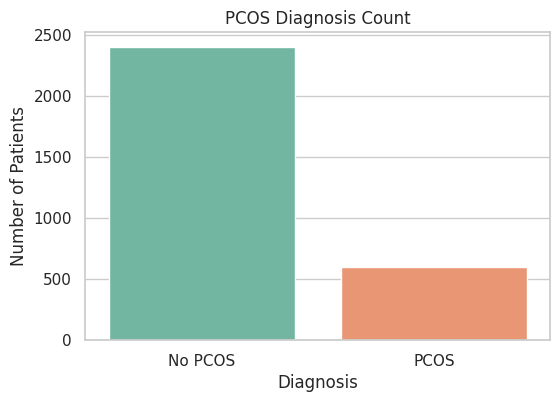

In [13]:
# Count of PCOS Diagnosis
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='PCOS_Diagnosis', palette='Set2')
plt.title("PCOS Diagnosis Count")
plt.xticks([0, 1], ['No PCOS', 'PCOS'])
plt.ylabel("Number of Patients")
plt.xlabel("Diagnosis")
plt.show()

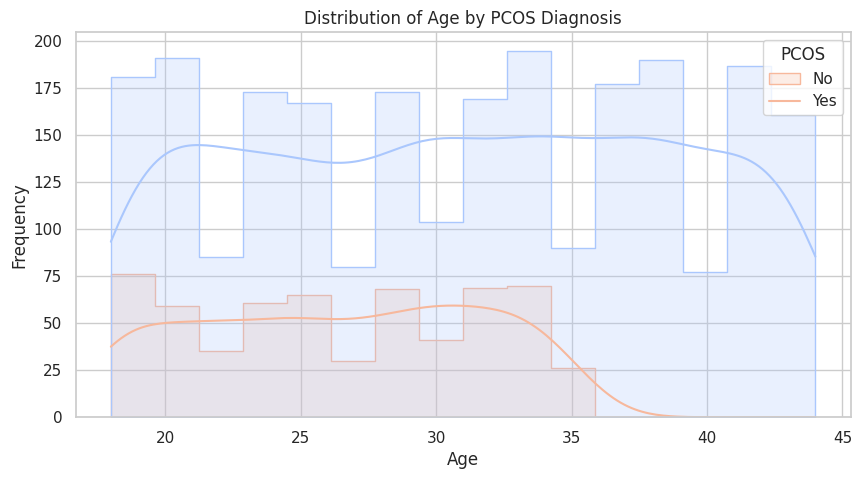

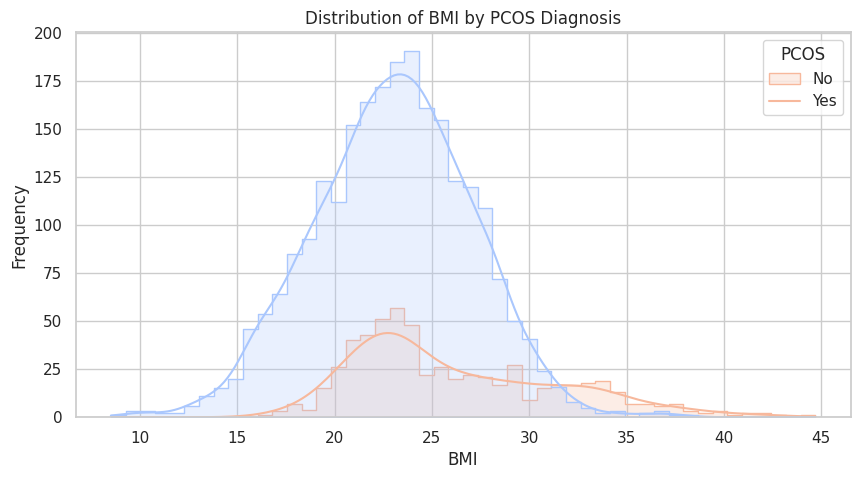

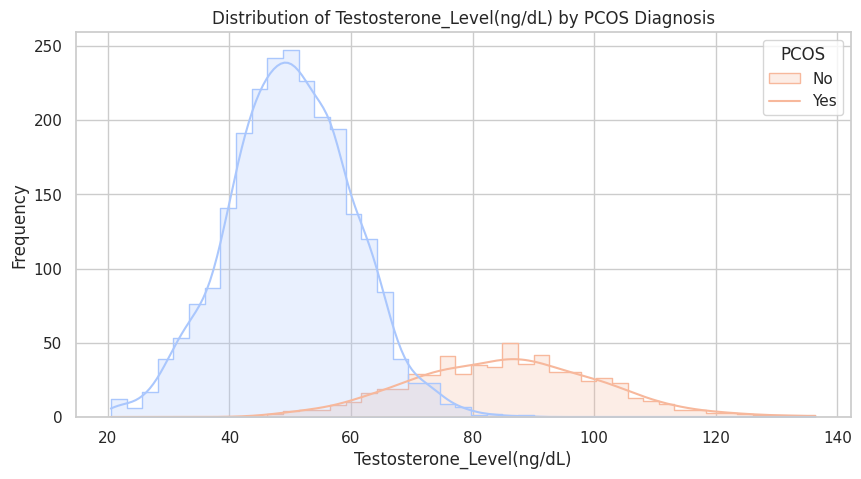

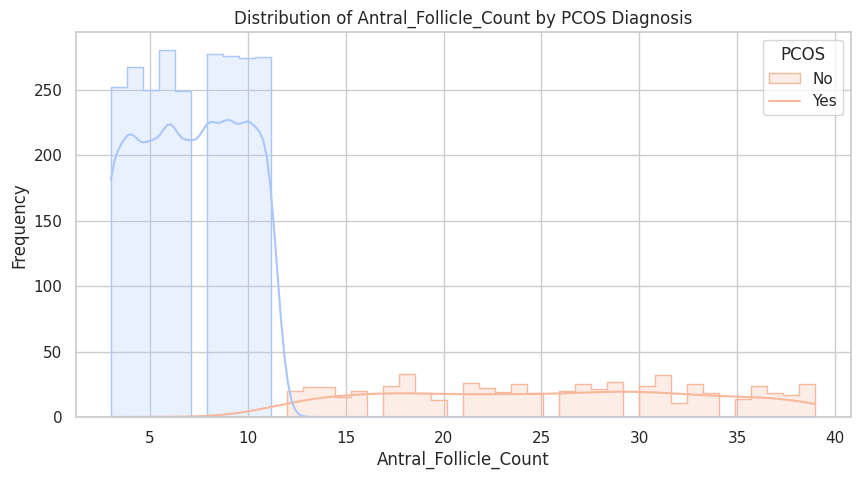

In [14]:
# Distribution Plots for Numeric Features
numeric_cols = ['Age', 'BMI', 'Testosterone_Level(ng/dL)', 'Antral_Follicle_Count']
for col in numeric_cols:
    plt.figure(figsize=(10, 5))
    sns.histplot(data=df, x=col, hue='PCOS_Diagnosis', kde=True, palette='coolwarm', element='step')
    plt.title(f"Distribution of {col} by PCOS Diagnosis")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.legend(title='PCOS', labels=['No', 'Yes'])
    plt.show()

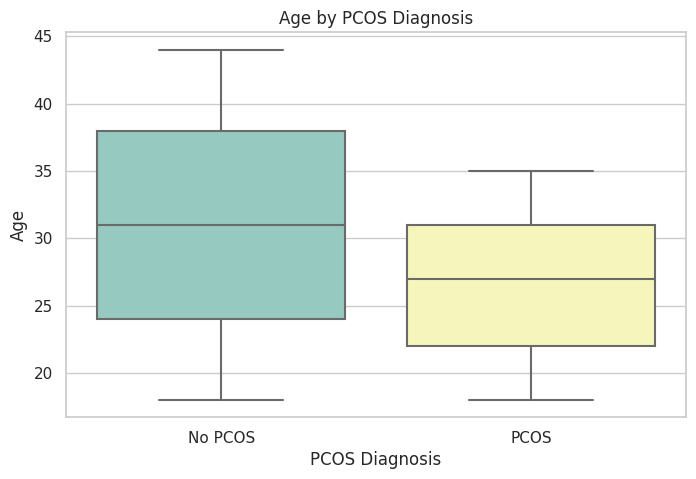

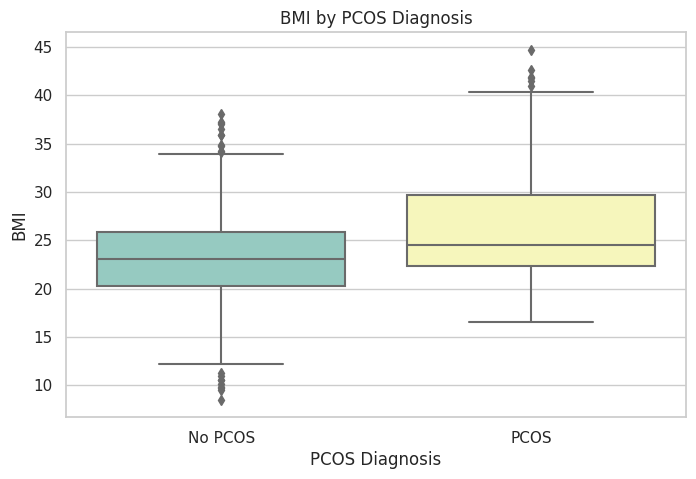

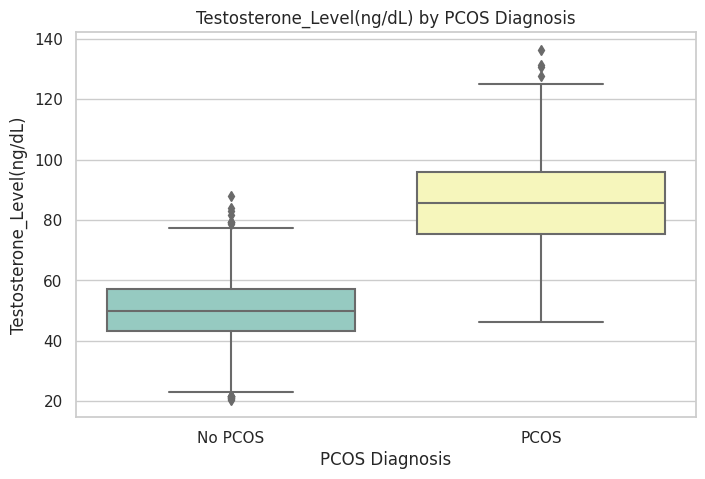

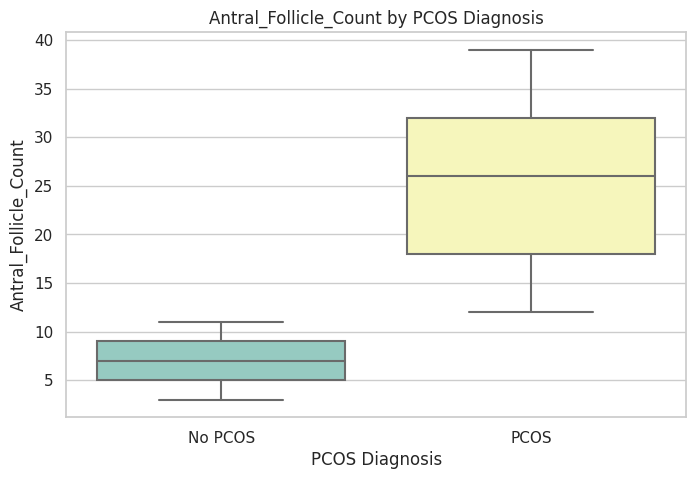

In [15]:
# Box Plots for visualizing spread and outliers
for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='PCOS_Diagnosis', y=col, palette='Set3')
    plt.title(f"{col} by PCOS Diagnosis")
    plt.xticks([0, 1], ['No PCOS', 'PCOS'])
    plt.xlabel("PCOS Diagnosis")
    plt.ylabel(col)
    plt.show()


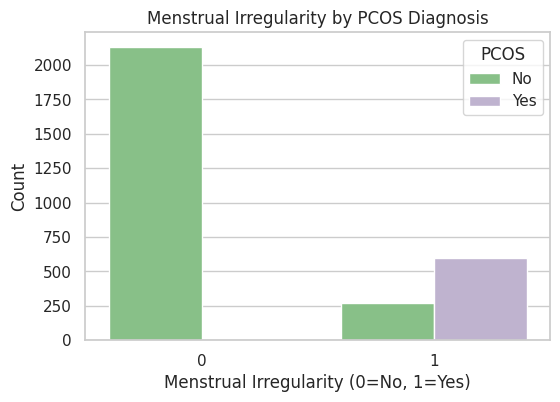

In [16]:
# Bar plot for Menstrual Irregularity
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Menstrual_Irregularity', hue='PCOS_Diagnosis', palette='Accent')
plt.title("Menstrual Irregularity by PCOS Diagnosis")
plt.xlabel("Menstrual Irregularity (0=No, 1=Yes)")
plt.ylabel("Count")
plt.legend(title='PCOS', labels=['No', 'Yes'])
plt.show()

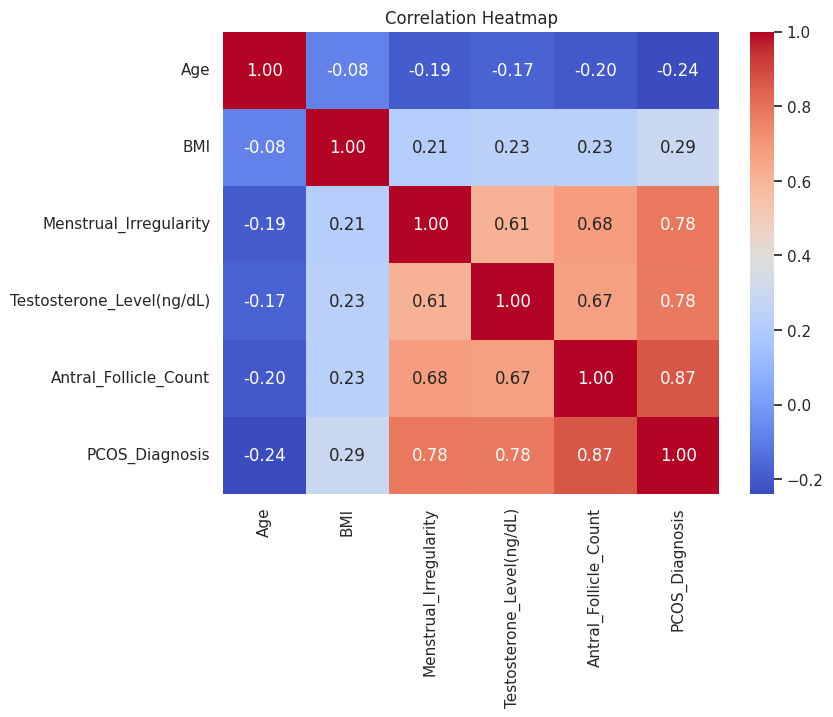

In [17]:
# Correlation heatmap (optional for numeric insight)
plt.figure(figsize=(8, 6))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## Pedictive modeling

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, ConfusionMatrixDisplay

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [19]:
# Only the required columns
cols = ['Age', 'BMI', 'Menstrual_Irregularity', 'Testosterone_Level(ng/dL)',
        'Antral_Follicle_Count', 'PCOS_Diagnosis']
df = df[cols]

# Check for nulls
print(df.isnull().sum())

# Fill or drop nulls if any
df = df.dropna()

# Convert categorical 'Menstrual_Irregularity' to numeric if not already
if df['Menstrual_Irregularity'].dtype == 'object':
    le = LabelEncoder()
    df['Menstrual_Irregularity'] = le.fit_transform(df['Menstrual_Irregularity'])

# Features and target
X = df.drop('PCOS_Diagnosis', axis=1)
y = df['PCOS_Diagnosis']

Age                          0
BMI                          0
Menstrual_Irregularity       0
Testosterone_Level(ng/dL)    0
Antral_Follicle_Count        0
PCOS_Diagnosis               0
dtype: int64


In [20]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42,
                                                    stratify=y)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



🔍 Model: Logistic Regression
Accuracy: 99.83 %
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       480
           1       0.99      1.00      1.00       120

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600


🔍 Model: Random Forest
Accuracy: 100.0 %
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       480
           1       1.00      1.00      1.00       120

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600


🔍 Model: Decision Tree
Accuracy: 100.0 %
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       480
           1       1.00      1.00

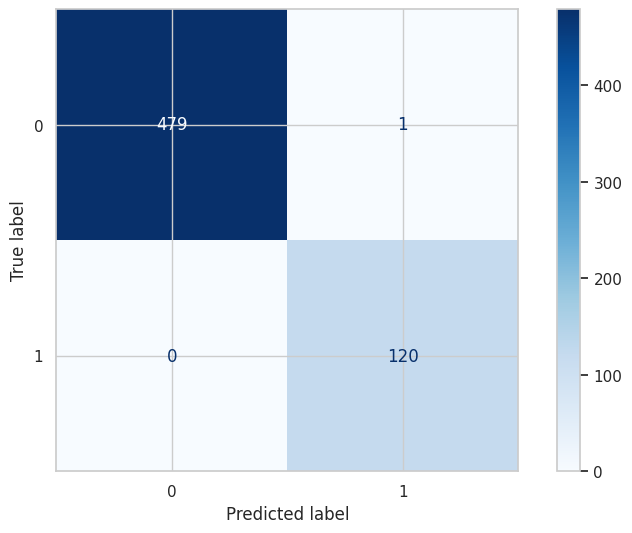

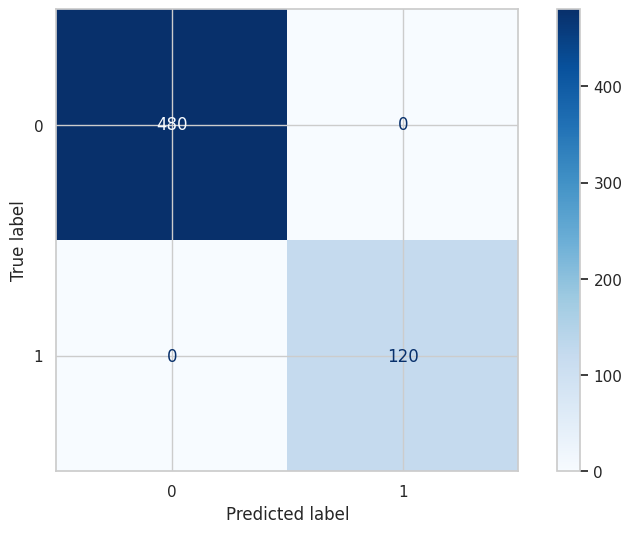

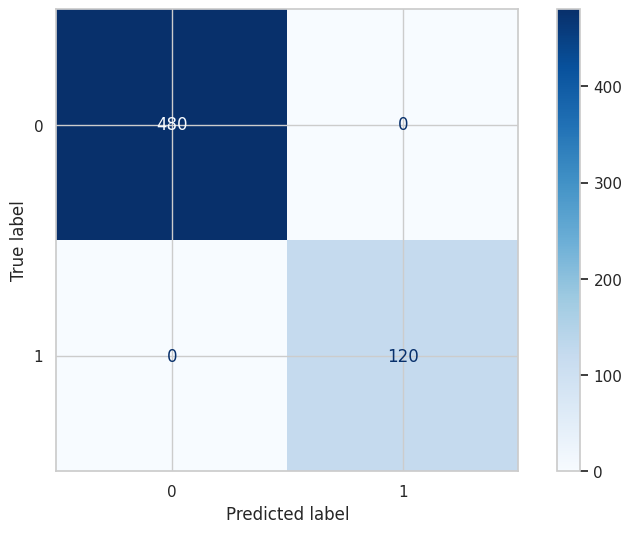

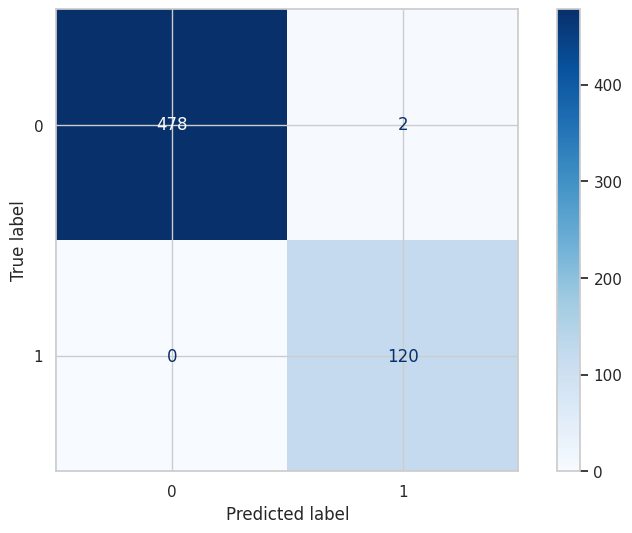

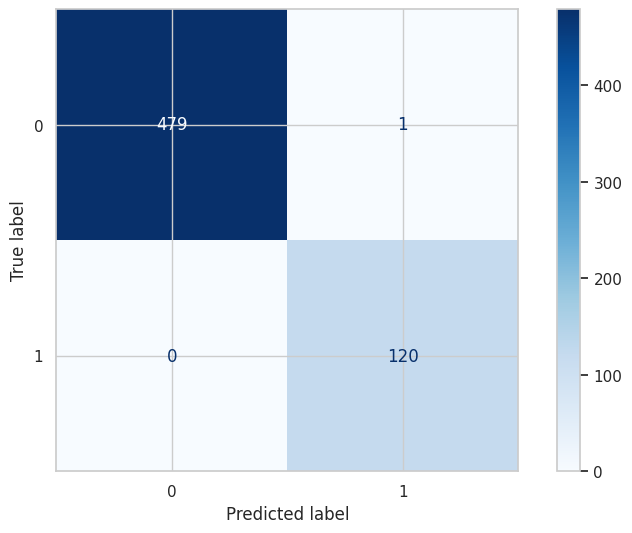

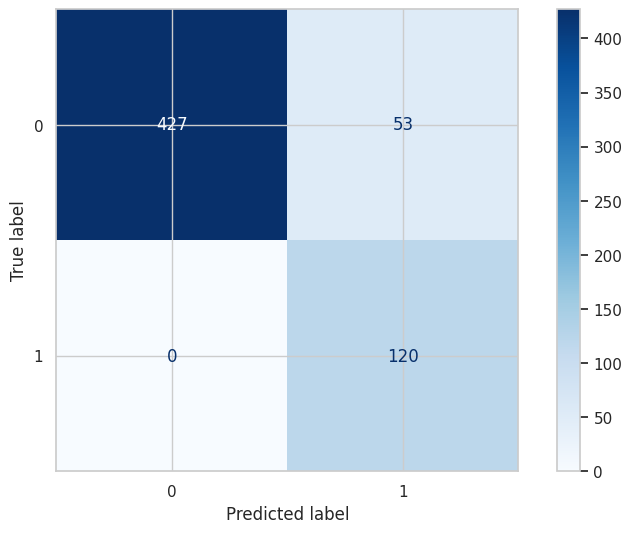

In [21]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Support Vector Machine": SVC(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

for name, model in models.items():
    print(f"\n🔍 Model: {name}")
    
    # Use scaled data for all except DecisionTree and RandomForest (they don’t need scaling)
    if name in ["Decision Tree", "Random Forest"]:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

    # Evaluation
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    print("Accuracy:", round(acc * 100, 2), "%")
    print("Classification Report:\n", classification_report(y_test, y_pred))
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap='Blues')


## Thank you...pls upvote!!!!!